# Meeting Notes Agent Evaluation

Runs the meeting notes agent from `meeting_agent.py` against 10 synthetic transcripts
(`transcripts.py`), once with an Anthropic model and once with an OpenAI model, then uses an
LLM judge to blind-score both providers on completeness, accuracy, and attribution.

## 1. Imports and setup

In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

from meeting_agent import run_agent
from transcripts import TRANSCRIPTS

from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

anthropic_model = ChatAnthropic(model="claude-opus-4-8")
openai_model = ChatOpenAI(model="gpt-4o")

# Judge model -- kept separate from the two providers being compared.
judge_model = ChatAnthropic(model="claude-opus-4-8")


## 2. Run both providers against all transcripts

In [2]:
results = []

for i, entry in enumerate(TRANSCRIPTS):
    label = entry["label"]
    transcript = entry["transcript"]

    print(f"[{i + 1}/{len(TRANSCRIPTS)}] Running transcript: {label}")

    print("  -> running Anthropic...")
    anthropic_result = run_agent(transcript, anthropic_model)

    print("  -> running OpenAI...")
    openai_result = run_agent(transcript, openai_model)

    results.append({
        "transcript_index": i,
        "transcript_label": label,
        "anthropic_result": anthropic_result,
        "openai_result": openai_result,
    })

print(f"\nDone. Ran {len(results)} transcripts through both providers.")


[1/10] Running transcript: Standard product sync with clear owners
  -> running Anthropic...
  -> running OpenAI...
[2/10] Running transcript: Meeting with no explicit decisions
  -> running Anthropic...
  -> running OpenAI...
[3/10] Running transcript: Very short meeting (5 minutes)
  -> running Anthropic...
  -> running OpenAI...
[4/10] Running transcript: Long meeting with many action items
  -> running Anthropic...
  -> running OpenAI...
[5/10] Running transcript: Meeting where nothing gets resolved
  -> running Anthropic...
  -> running OpenAI...
[6/10] Running transcript: Meeting with ambiguous ownership
  -> running Anthropic...
  -> running OpenAI...
[7/10] Running transcript: Meeting with lots of side discussion and off-topic content
  -> running Anthropic...
  -> running OpenAI...
[8/10] Running transcript: Technical engineering standup
  -> running Anthropic...
  -> running OpenAI...
[9/10] Running transcript: Executive meeting with formal language
  -> running Anthropic...


## 3. LLM judge evaluation

The judge only ever sees "Provider A" and "Provider B" -- not which model produced which
output -- so the scoring below is blind.

In [3]:
import json

from langchain_core.messages import HumanMessage

JUDGE_PROMPT = """You are an impartial judge evaluating two AI systems that each extracted
structured meeting notes (action items, decisions made, and open questions) from the same
raw meeting transcript.

Score each provider from 1 to 3 on each of these dimensions:
- completeness: did it capture everything relevant that was actually in the transcript?
- accuracy: is everything it reported actually supported by the transcript (no invented items)?
- attribution: when an owner was mentioned or implied, did it correctly assign it (and correctly
  leave ownership unspecified when the transcript did not name one)?

Write out your detailed reasoning for each provider BEFORE assigning its scores. Be specific --
reference what was in the transcript vs. what each provider reported.

Respond with JSON ONLY, no other text, in exactly this structure:
{{
  "provider_a": {{"completeness": <1-3>, "accuracy": <1-3>, "attribution": <1-3>, "reasoning": "<detailed reasoning>"}},
  "provider_b": {{"completeness": <1-3>, "accuracy": <1-3>, "attribution": <1-3>, "reasoning": "<detailed reasoning>"}}
}}

ORIGINAL TRANSCRIPT:
{transcript}

PROVIDER A OUTPUT:
Action items:
{a_action_items}

Decisions made:
{a_decisions}

Open questions:
{a_open_questions}

PROVIDER B OUTPUT:
Action items:
{b_action_items}

Decisions made:
{b_decisions}

Open questions:
{b_open_questions}
"""


def parse_judge_json(content) -> dict:
    """Extract and parse the JSON object from the judge's response."""
    text = content if isinstance(content, str) else str(content)
    text = text.strip()
    # Judges sometimes wrap JSON in a code fence despite instructions -- strip it if present.
    if text.startswith("```"):
        text = text.strip("`")
        if text.lower().startswith("json"):
            text = text[4:]
    return json.loads(text.strip())


for entry in results:
    a = entry["anthropic_result"]
    b = entry["openai_result"]

    prompt = JUDGE_PROMPT.format(
        transcript=TRANSCRIPTS[entry["transcript_index"]]["transcript"],
        a_action_items=a["action_items"],
        a_decisions=a["decisions"],
        a_open_questions=a["open_questions"],
        b_action_items=b["action_items"],
        b_decisions=b["decisions"],
        b_open_questions=b["open_questions"],
    )

    response = judge_model.invoke([HumanMessage(content=prompt)])
    scores = parse_judge_json(response.content)

    entry["scores"] = scores

    print(f"Judged transcript {entry['transcript_index'] + 1}/{len(results)}: {entry['transcript_label']}")


Judged transcript 1/10: Standard product sync with clear owners
Judged transcript 2/10: Meeting with no explicit decisions
Judged transcript 3/10: Very short meeting (5 minutes)
Judged transcript 4/10: Long meeting with many action items
Judged transcript 5/10: Meeting where nothing gets resolved
Judged transcript 6/10: Meeting with ambiguous ownership
Judged transcript 7/10: Meeting with lots of side discussion and off-topic content
Judged transcript 8/10: Technical engineering standup
Judged transcript 9/10: Executive meeting with formal language
Judged transcript 10/10: Chaotic meeting where people talk over each other


## 4. Readable audit trail

Full outputs, full judge reasoning (not summarized), scores, and a flag for any dimension
where the two providers' scores differ by more than 1.

In [4]:
import textwrap
from itertools import zip_longest


def print_side_by_side(left_label, left_text, right_label, right_text, col_width=48):
    left_lines = []
    for para in left_text.split("\n"):
        left_lines.extend(textwrap.wrap(para, col_width) or [""])

    right_lines = []
    for para in right_text.split("\n"):
        right_lines.extend(textwrap.wrap(para, col_width) or [""])

    print(f"{left_label:<{col_width}} | {right_label}")
    print("-" * col_width + "-+-" + "-" * col_width)
    for left, right in zip_longest(left_lines, right_lines, fillvalue=""):
        print(f"{left:<{col_width}} | {right}")


DIMENSIONS = ["completeness", "accuracy", "attribution"]

for entry in results:
    a_result = entry["anthropic_result"]
    b_result = entry["openai_result"]
    a_scores = entry["scores"]["provider_a"]
    b_scores = entry["scores"]["provider_b"]

    any_gap = any(abs(a_scores[dim] - b_scores[dim]) > 1 for dim in DIMENSIONS)

    print("=" * 100)
    print(f"Transcript {entry['transcript_index'] + 1}: {entry['transcript_label']}")
    if any_gap:
        print("FLAGGED: provider scores differ by more than 1 on at least one dimension")
    print("=" * 100)

    print("\n--- ACTION ITEMS ---")
    print_side_by_side("Provider A", a_result["action_items"], "Provider B", b_result["action_items"])

    print("\n--- DECISIONS MADE ---")
    print_side_by_side("Provider A", a_result["decisions"], "Provider B", b_result["decisions"])

    print("\n--- OPEN QUESTIONS ---")
    print_side_by_side("Provider A", a_result["open_questions"], "Provider B", b_result["open_questions"])

    print("\n--- JUDGE REASONING: PROVIDER A ---")
    print(a_scores["reasoning"])

    print("\n--- JUDGE REASONING: PROVIDER B ---")
    print(b_scores["reasoning"])

    print("\n--- SCORES ---")
    print(f"{'Dimension':<15}{'Provider A':<12}{'Provider B':<12}{'Flag'}")
    for dim in DIMENSIONS:
        a_val = a_scores[dim]
        b_val = b_scores[dim]
        flag = "<-- differs by >1" if abs(a_val - b_val) > 1 else ""
        print(f"{dim:<15}{a_val:<12}{b_val:<12}{flag}")

    print()


Transcript 1: Standard product sync with clear owners

--- ACTION ITEMS ---
Provider A                                       | Provider B
-------------------------------------------------+-------------------------------------------------
- Add rate limiting to the signup API before     | - Add rate limiting to the backend before
prod, by Friday (Owner: Marcus)                  | deployment to production by Friday (Owner:
- Review the empty state illustrations by        | Marcus)
Wednesday morning (Owner: Priya)                 | - Review empty state illustrations by Wednesday
- File both bugs (skip button state and          | morning (Owner: Priya)
illustration loading on slow connections) today  | - File two bugs related to the onboarding flow
(Owner: Tomas)                                   | today (Owner: Tomas)
- Fix the skip button bug that doesn't save      | - Fix the "skip" button bug (Owner: Marcus)
state (Owner: Marcus)                            | - Fix the lazy-loading issu

## 5. Statistical analysis and visualization

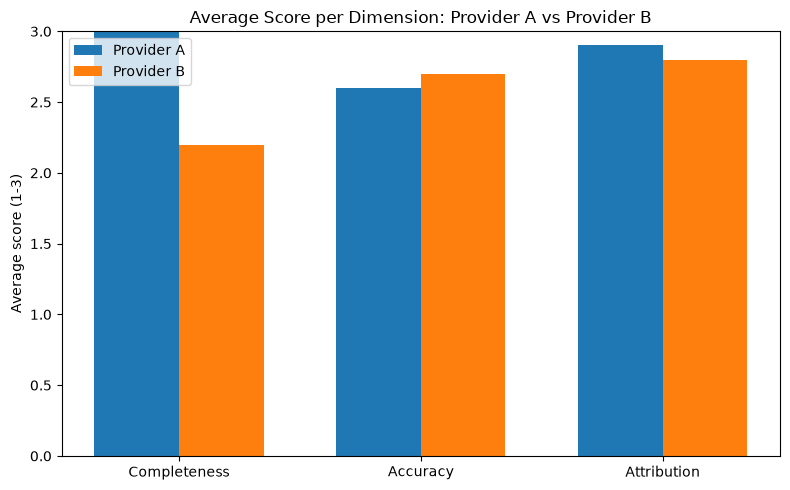

In [5]:
import matplotlib.pyplot as plt

a_scores_by_dim = {dim: [] for dim in DIMENSIONS}
b_scores_by_dim = {dim: [] for dim in DIMENSIONS}

for entry in results:
    for dim in DIMENSIONS:
        a_scores_by_dim[dim].append(entry["scores"]["provider_a"][dim])
        b_scores_by_dim[dim].append(entry["scores"]["provider_b"][dim])

a_averages = [sum(a_scores_by_dim[dim]) / len(a_scores_by_dim[dim]) for dim in DIMENSIONS]
b_averages = [sum(b_scores_by_dim[dim]) / len(b_scores_by_dim[dim]) for dim in DIMENSIONS]

# --- Bar chart: average score per dimension ---
x = range(len(DIMENSIONS))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([p - width / 2 for p in x], a_averages, width, label="Provider A")
ax.bar([p + width / 2 for p in x], b_averages, width, label="Provider B")
ax.set_xticks(list(x))
ax.set_xticklabels([d.capitalize() for d in DIMENSIONS])
ax.set_ylabel("Average score (1-3)")
ax.set_ylim(0, 3)
ax.set_title("Average Score per Dimension: Provider A vs Provider B")
ax.legend()
plt.tight_layout()
plt.show()


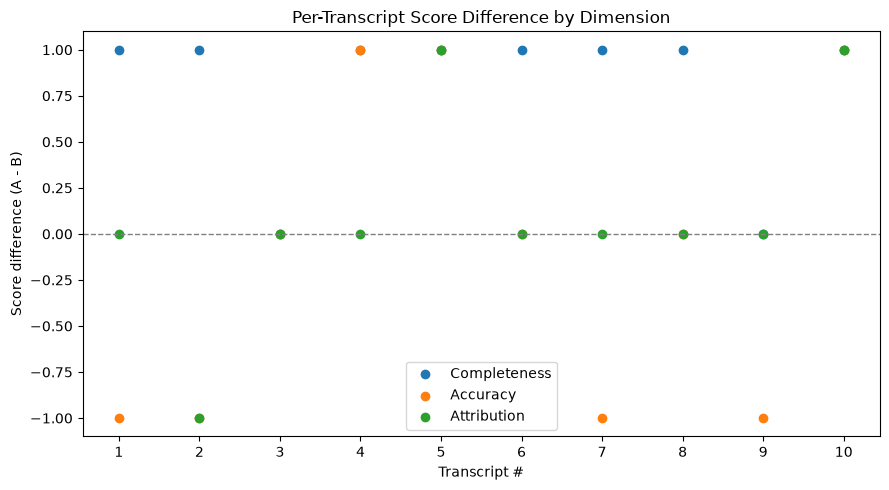

In [6]:
# --- Scatter plot: per-transcript score difference (A - B) across dimensions ---
fig, ax = plt.subplots(figsize=(9, 5))
transcript_numbers = [entry["transcript_index"] + 1 for entry in results]

for dim in DIMENSIONS:
    diffs = [
        entry["scores"]["provider_a"][dim] - entry["scores"]["provider_b"][dim]
        for entry in results
    ]
    ax.scatter(transcript_numbers, diffs, label=dim.capitalize())

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Transcript #")
ax.set_ylabel("Score difference (A - B)")
ax.set_title("Per-Transcript Score Difference by Dimension")
ax.set_xticks(transcript_numbers)
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# --- Win rate summary ---
print("WIN RATE SUMMARY (per dimension)")
print("=" * 60)
for dim in DIMENSIONS:
    a_wins = sum(
        1 for entry in results
        if entry["scores"]["provider_a"][dim] > entry["scores"]["provider_b"][dim]
    )
    b_wins = sum(
        1 for entry in results
        if entry["scores"]["provider_b"][dim] > entry["scores"]["provider_a"][dim]
    )
    ties = len(results) - a_wins - b_wins
    print(f"{dim.capitalize():<15} Provider A wins: {a_wins:<4} Provider B wins: {b_wins:<4} Ties: {ties}")

# --- Summary table of all scores ---
print("\nSUMMARY TABLE (all scores)")
print("=" * 90)
print(f"{'#':<4}{'Label':<38}{'Dimension':<14}{'A':<5}{'B':<5}{'Diff'}")
print("-" * 90)
for entry in results:
    for dim in DIMENSIONS:
        a_val = entry["scores"]["provider_a"][dim]
        b_val = entry["scores"]["provider_b"][dim]
        print(
            f"{entry['transcript_index'] + 1:<4}"
            f"{entry['transcript_label'][:36]:<38}"
            f"{dim:<14}{a_val:<5}{b_val:<5}{a_val - b_val}"
        )

print("\nNOTE: All scoring above was performed blind (the judge only ever saw 'Provider A' /")
print("'Provider B'). Revealing the mapping now that scoring is complete:")
print("  Provider A = Anthropic (claude-opus-4-8)")
print("  Provider B = OpenAI (gpt-4o)")


WIN RATE SUMMARY (per dimension)
Completeness    Provider A wins: 8    Provider B wins: 0    Ties: 2
Accuracy        Provider A wins: 3    Provider B wins: 4    Ties: 3
Attribution     Provider A wins: 2    Provider B wins: 1    Ties: 7

SUMMARY TABLE (all scores)
#   Label                                 Dimension     A    B    Diff
------------------------------------------------------------------------------------------
1   Standard product sync with clear own  completeness  3    2    1
1   Standard product sync with clear own  accuracy      2    3    -1
1   Standard product sync with clear own  attribution   3    3    0
2   Meeting with no explicit decisions    completeness  3    2    1
2   Meeting with no explicit decisions    accuracy      2    3    -1
2   Meeting with no explicit decisions    attribution   2    3    -1
3   Very short meeting (5 minutes)        completeness  3    3    0
3   Very short meeting (5 minutes)        accuracy      3    3    0
3   Very short meeting (5 